In [1]:
from copy import deepcopy
from pathlib import Path

from sklearn.model_selection import train_test_split

from torch import nn
from torch.utils.data import DataLoader
from torchvision.models import (
    resnet18,
    ResNet18_Weights,
    resnet34,
    ResNet34_Weights,
    resnet50,
    ResNet50_Weights,
    resnet101,
    ResNet101_Weights,
    resnet152,
    ResNet152_Weights,
    densenet121,
    DenseNet121_Weights,
    densenet161,
    DenseNet161_Weights,
    densenet169,
    DenseNet169_Weights,
    densenet201,
    DenseNet201_Weights,
    mobilenet_v2,
    MobileNet_V2_Weights,
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights,
    mobilenet_v3_large,
    MobileNet_V3_Large_Weights,
)
from torchvision.transforms import v2
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, Timer
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger
from torchinfo import summary
import segmentation_models_pytorch as smp
from utils import (
    OCTDataset, 
    IterableOCTDataset, 
    plotimg, 
    LitSupervised, 
    OCTRandAugment, 
    TransferLearningModel,
    TransferLearning,
    GLOBAL_CONFIG,
    product_dict, 
    LOGDIR, 
)
from core_utils import stringify_map, get_normal_statistics

/home/polyester/Desktop/Programming/OCT-Project/.venv/lib/python3.13/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [2]:
dataset = OCTDataset.from_path("OCTDataMendeley_resized")

In [3]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    dataset.paths, 
    dataset.targets,
    stratify=dataset.targets, 
    test_size=1000, 
    random_state=42
)
train_paths, val_paths = train_test_split(
    train_paths, 
    stratify=train_labels, 
    test_size=0.2, 
    random_state=42
)

In [4]:
train_dataset = OCTDataset(train_paths)
val_dataset = OCTDataset(val_paths)
test_dataset = OCTDataset(test_paths)
del dataset
len(train_dataset), len(val_dataset), len(test_dataset)

(86647, 21662, 1000)

In [5]:
OCTDataset.classes()

['DME', 'AMD', 'DRUSEN', 'DR', 'CNV', 'NORMAL', 'CSR', 'MH']

In [6]:
#get_normal_statistics(IterableOCTDataset(train_dataset))
#(tensor([48.6167, 48.6167, 48.6167]), tensor([56.4110, 56.4110, 56.4110]))

In [7]:
_index = 6
path, _ = test_dataset.path_instance_pair(_index)
instance, label = test_dataset[_index]

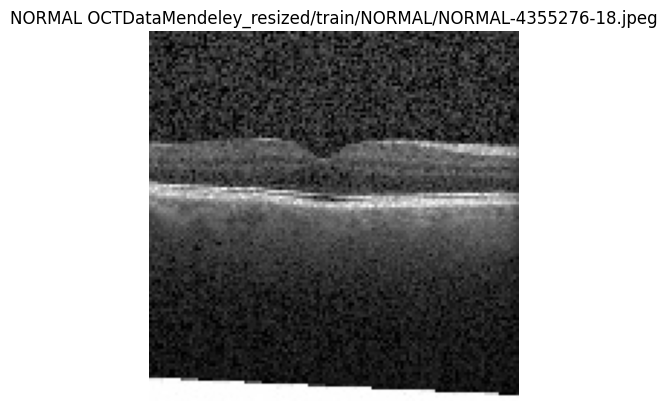

In [8]:
plotimg(instance, f"{OCTDataset.classes()[label]} {path}")

In [9]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=GLOBAL_CONFIG["batch_size"], 
    num_workers=7,
)
validation_loader = DataLoader(
    val_dataset, 
    batch_size=GLOBAL_CONFIG["batch_size"], 
    num_workers=7,
)

In [10]:
TransferLearning.models = {
    "mobilenet_v2": TransferLearningModel(mobilenet_v2, MobileNet_V2_Weights.IMAGENET1K_V2),
    "mobilenet_v3_small": TransferLearningModel(mobilenet_v3_small, MobileNet_V3_Small_Weights.IMAGENET1K_V1),
    "mobilenet_v3_large": TransferLearningModel(mobilenet_v3_large, MobileNet_V3_Large_Weights.IMAGENET1K_V2),
    "resnet18": TransferLearningModel(resnet18, ResNet18_Weights.IMAGENET1K_V1),
    "resnet34": TransferLearningModel(resnet34, ResNet34_Weights.IMAGENET1K_V1),
    "resnet50": TransferLearningModel(resnet50, ResNet50_Weights.IMAGENET1K_V1),
    "resnet101": TransferLearningModel(resnet101, ResNet101_Weights.IMAGENET1K_V2),
    "resnet152": TransferLearningModel(resnet152, ResNet152_Weights.IMAGENET1K_V1),
    #"densenet121": TransferLearningModel(densenet121, DenseNet121_Weights.IMAGENET1K_V1),
    #"densenet161": TransferLearningModel(densenet161, DenseNet161_Weights.IMAGENET1K_V1),
    #"densenet169": TransferLearningModel(densenet169, DenseNet169_Weights.IMAGENET1K_V1),
    #"densenet201": TransferLearningModel(densenet201, DenseNet201_Weights.IMAGENET1K_V1),
}

In [11]:
def tune_model(configs):
    LOGCONFIG = "config.txt"
    log_config_path = LOGDIR / Path(LOGCONFIG)

    last_config = None
    if log_config_path.exists():
        with open(log_config_path, "r") as fconfig:
            last_config = eval(fconfig.read())

    configarr = list(product_dict(configs))
    last_index = configarr.index(last_config) if isinstance(last_config, dict) else None
    
    current_config = None
    current_name = None
    try:
        for current_index, config in enumerate(configarr):
            if isinstance(last_index, int) and current_index < last_index:
                continue
            ckpt_path = None
            current_name = stringify_map(config, ", ")
            version_name = stringify_map(config)
            
            if current_index == last_index:
               print(f"Resuming at {current_name}")
               ckpts_path = Path(LOGDIR, version_name, "checkpoints")
               if ckpts_path.exists():
                   ckpts_arr = sorted(list(ckpts_path.iterdir()))
                   ckpt_path = None if ckpts_arr == [] else ckpts_arr[-1]
            else:
               print(current_name)

            current_config = config

            logger = TensorBoardLogger(
               save_dir=".",
               name=LOGDIR,
               version=version_name,
            )
            trainer = L.Trainer(
               logger=logger,
               accelerator="gpu",
               callbacks=EarlyStopping(
                  monitor=LitSupervised.VALIDATION_LOSS, 
                  mode="min",
                  min_delta=1e-3, 
                  patience=8,
               ),
            )
            litmodel = LitSupervised(config)
            
            trainer.fit(
               model=litmodel, 
               train_dataloaders=train_loader, val_dataloaders=validation_loader,
               ckpt_path=ckpt_path,
            )

    except KeyboardInterrupt:
        if isinstance(current_config, dict):
            print(f"Saving {current_name}...")
            with open(log_config_path, "w") as fconfig:
                fconfig.write(str(current_config))

In [ ]:
def train_model(config, ckpt_config = None):
   current_name = stringify_map(config, ", ")
   version_name = stringify_map(config)
   logdir = config["logdir"]
   print(current_name)
   logger = TensorBoardLogger(
      save_dir=".",
      name=logdir,
      version=version_name,
   )
   litmodel = LitSupervised(config, OCTDataset.classes())
   metric_names = litmodel.metric_names()
   timer = Timer()
   trainer = L.Trainer(
      logger=logger,
      accelerator="gpu",
      callbacks=[
         timer,
         EarlyStopping(
            monitor=f"{LitSupervised.SET_NAME_VAL}_loss", 
            mode="min",
            min_delta=1e-3, 
            patience=8,
         ),
      ] + [
         ModelCheckpoint(
            dirpath=None,  # Uses logger's default directory
            monitor=metric_name,  # Metric to monitor
            filename="top-"+metric_name+"-epoch:{epoch:d}-step:{step:d}-{"+metric_name+"}",
            save_top_k=1,  # Save top 1 checkpoints
            mode="max",  # Save highest
            save_last=i==0,  # Also save the last checkpoint
         ) for i, metric_name in enumerate(metric_names)
      ],
   )
   ckpt_path = None
   if isinstance(ckpt_config, dict):
      ckpt_version_name = stringify_map(ckpt_config)
      ckpts_path = Path(logdir, ckpt_version_name, "checkpoints")
      ckpt_path = sorted(list(ckpts_path.iterdir()))[-1]
   trainer.fit(
      model=litmodel, 
      train_dataloaders=train_loader, val_dataloaders=validation_loader,
      ckpt_path=ckpt_path,
   )
   train_time = timer.time_elapsed("train")
   val_time = timer.time_elapsed("validate")
   total_fit_time = train_time + val_time
   print(f"Training completed in {train_time} secs")
   print(f"Validation completed in {train_time} secs")
   print(f"Total time is {total_fit_time} secs")

In [13]:
#summary(TransferLearning.models["densenet161"].model, input_size=(80,3,128,128), depth=2)

In [14]:
# model_name = "mobilenet_v2"
# TransferLearning.replace_head(model_name, len(OCTDataset.classes()))

# tlmodel = TransferLearning.models[model_name]
# model = tlmodel.model
# model
# model = model.to("cuda")
# img, label = train_dataset[0]
# img = img.to("cuda")
# model(img)

In [15]:
for model_name in TransferLearning.models:
    print(f"Running {model_name}:")
    train_model(
        {
            "run": "step1", 
            "logdir": "logs_stratified",
            "model": model_name, 
            "magnitude": 0, 
            "lr": 1e-3
        },
    )
    train_model(
        {
            "run": "step2", 
            "logdir": "logs_stratified",
            "model": model_name, 
            "magnitude": 0, 
            "lr": 1e-4
        },
        {
            "run": "step1", 
            "logdir": "logs_stratified",
            "model": model_name, 
            "magnitude": 0, 
            "lr": 1e-3
        }
    )

Running mobilenet_v2:
run:step1, logdir:logs_stratified, model:mobilenet_v2, magnitude:0, lr:0.001
Freezing weights


AttributeError: type object 'LitSupervised' has no attribute 'VALIDATION_LOSS'